In [3]:
## To do:
# Give input dimensionality reduction instead of recalculating

suppressPackageStartupMessages(library(SingleCellExperiment))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(argparse))
suppressPackageStartupMessages(library(miloR))
suppressPackageStartupMessages(library(patchwork))

In [11]:

#####################
## Define settings ##
#####################
here::i_am("processing/1_create_seurat_rna.R")
source(here::here("settings.R"))
source(here::here("utils.R"))
source(here::here("mapping/run/mnn/mapping_functions.R"))
test = TRUE

if(test){
## START TEST ##
    args = list()
args$sce <- io$rna.sce
args$metadata <- io$metadata
args$stage <- c('E8.5')#, 'E8.5', 'E9.5')
args$metadata <- paste0(io$basedir,"/results/rna/mapping/sample_metadata_after_mapping.txt.gz")
args$pca_file <- paste0(io$basedir,"/results/rna/dimensionality_reduction/no_ExE/sce/sample/pca_features2500_pcs40.txt.gz")
args$n_neighbors = 45 
args$prop = 0.15 # put at 0.15 - 0.2
args$remove_ExE_cells <- FALSE
args$tdTom_corr = FALSE
args$outdir <- paste0(io$basedir,"/results/rna/MiloR/test")
## END TEST ##
}


here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/code



In [83]:
io$rna.atlas.metadata

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/pijuansala2019_gastrulation10x/sample_metadata_extended.txt.gz"

In [5]:

# If passing multiple timepoints split in vector
args$stage = strsplit(args$stage, "_")[[1]] 

dir.create(args$outdir, recursive=TRUE, showWarnings = FALSE)

In [8]:
##########################
## Load sample metadata ##
##########################

sample_metadata <- fread(args$metadata) %>%
   .[pass_rnaQC==TRUE & doublet_call==FALSE & stage %in% args$stage] %>%
    .[,pool:=stringr::str_replace_all(sample,opts$sample2pool)]


if(args$tdTom_corr!='True'){
    sample_metadata = sample_metadata[tdTom==tdTom_corr]
}

if(test){
    sample_metadata = sample_metadata[sample(1:nrow(sample_metadata), nrow(sample_metadata)/10)]
}

In [10]:
###############
## Load data ##
###############

# Load RNA expression data as SingleCellExperiment object
sce <- load_SingleCellExperiment(args$sce, cells=sample_metadata$cell, normalise = TRUE)

# Add sample metadata as colData
colData(sce) <- sample_metadata %>% tibble::column_to_rownames("cell") %>% DataFrame


ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'as.matrix': Input is empty or only contains BOM or terminal control characters


In [60]:
# Get PCA
pca = fread(args$pca_file)[cell %in% colnames(sce)]

sce = sce[,pca$cell]
pca = pca[match(colnames(sce), cell)] %>% tibble::column_to_rownames("cell") %>% as.matrix
reducedDim(sce,"PCA") = pca
args$npcs = dim(pca)[2]

In [47]:
# Get UMAP
meta_atlas <- fread(io$rna.atlas.metadata)
umap.dt <- meta_atlas %>%
    .[,c("cell","umapX","umapY")] %>%
    .[match(sce$closest.cell_mnn, cell)] %>%
    .[, cell := colnames(sce)]

umap = umap.dt[match(colnames(sce), cell)] %>% tibble::column_to_rownames("cell") %>% as.matrix
reducedDim(sce,"UMAP") = umap

In [50]:
########################
## Create MILO object ##
########################

# create object
Milo_sce <- Milo(sce)

In [51]:
Milo_sce

class: Milo 
dim: 29453 3137 
metadata(0):
assays(2): counts logcounts
rownames(29453): Xkr4 Gm1992 ... CAAA01147332.1 tomato-td
rowData names(0):
colnames(3137): SLX-20795_SITTA11_HKTG2DRXY#AAACGCTAGTGATTCC-1
  SLX-20795_SITTA11_HKTG2DRXY#AAGTTCGAGGAATTAC-1 ...
  SLX-20795_SITTH11_HKTG2DRXY#TTTCGATAGACCATGG-1
  SLX-20795_SITTH11_HKTG2DRXY#TTTGTTGCAATGAGCG-1
colData names(21): sample barcode ... closest.cell_mnn pool
reducedDimNames(2): PCA UMAP
mainExpName: RNA
altExpNames(0):
nhoods dimensions(2): 1 1
nhoodCounts dimensions(2): 1 1
nhoodDistances dimension(1): 0
graph names(0):
nhoodIndex names(1): 0
nhoodExpression dimension(2): 1 1
nhoodReducedDim names(0):
nhoodGraph names(0):
nhoodAdjacency dimension(2): 1 1

In [52]:
colData(Milo_sce)$sample_ko = paste0(colData(Milo_sce)$sample, '_',  colData(Milo_sce)$tdTom_corr)


In [61]:
# Build graph
Milo_sce <- buildGraph(Milo_sce, 
                       k = args$n_neighbors, 
                       d = args$npcs, 
                       reduced.dim = "PCA")

Constructing kNN graph with k:45



In [62]:
# Identify neighbourhoods from NN-cells
# lower prop for larger datasets
Milo_sce <- makeNhoods(Milo_sce, 
                       prop = args$prop, 
                       k = args$n_neighbors, 
                       d = args$npcs, 
                       refined = TRUE, 
                       reduced_dims = "PCA")

Checking valid object

Running refined sampling with reduced_dim



In [73]:
outfile

character(0)

In [74]:



# count cells of different samples per neighbourhood
Milo_sce <- countCells(Milo_sce, meta.data = as.data.frame(colData(Milo_sce)), sample="sample_ko")

# Calculate Neighbourhood Distances (most time consuming step)
Milo_sce <- calcNhoodDistance(Milo_sce, d=args$npcs, reduced.dim = "PCA")

# Build neighbourhood graph
Milo_sce <- buildNhoodGraph(Milo_sce)

# Save MILO object
outfile = sprintf("%s/%s_Milo_tdTomcorr%s.rds",args$outdir, paste(args$stage, collapse ='_'), args$tdTom_corr)
saveRDS(Milo_sce, outfile)

# Embryo design table
embryo_design <- data.frame(colData(Milo_sce))[,c("sample_ko", "sample", 'tdTom_corr', 'tdTom', 'stage', 'pool')]

embryo_design <- distinct(embryo_design)
rownames(embryo_design) <- embryo_design$sample_ko

# Test differential abundance per hood
da_results <- testNhoods(Milo_sce, design = ~ pool + tdTom_corr, design.df = embryo_design, reduced.dim="PCA")

# Save MILO results
outfile = sprintf("%s/%s_Milo_tdTomcorr%s_DAresults.csv",args$outdir, paste(args$stage, collapse ='_'), args$tdTom_corr)
write.csv(da_results, outfile, row.names=FALSE)


##################
## Plot results ##
##################

p1 = ggplot(da_results, aes(PValue)) + 
    geom_histogram(bins=50) + 
    theme_bw()

p2 = ggplot(da_results, aes(logFC, -log10(SpatialFDR))) + 
    geom_point() +
    geom_hline(yintercept = 1) + ## Mark significance threshold (10% FDR)
    theme_bw()


## Plot single-cell UMAP
p3 = plotReducedDim(Milo_sce, dimred = "UMAP", colour_by="tdTom_corr", text_by = "celltype.mapped_mnn", 
                          text_size = 3, point_size=0.3, text_colour = "grey30") +
    scale_color_manual(values=opts$tdTom.color, name = 'tdTom') + 
    theme_void() + 
    theme(legend.position='right') +
    guides(fill="none")

## Plot neighbourhood graph
p4 = plotNhoodGraphDA(Milo_sce, da_results, layout="UMAP",alpha=0.05) 

# plot stats + graphs
outfile = sprintf("%s/%s_Milo_tdTomcorr%s_plots.pdf",args$outdir, paste(args$stage, collapse ='_'), args$tdTom_corr)
pdf(outfile, width=14, height = 7)
    p1 + p2
    p3 + p4 +
      plot_layout(guides="collect")
dev.off()

Checking meta.data validity

Counting cells in neighbourhoods

Using TMM normalisation

Performing spatial FDR correction withk-distance weighting

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


png 
  2

Found 177 DA neighbourhoods at FDR 10%

nhoodAdjacency found - using for nhood grouping

Converting celltype.mapped_mnn to factor...

Converting group.by to factor...

Warning message:
“Removed 76 rows containing missing values.”


png 
  2

,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR,NhoodGroup,celltype.mapped_mnn,celltype.mapped_mnn_fraction
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
1,-0.8597724,13.11434,2.759915,1.005049e-01,1.359772e-01,1,1.336118e-01,1,Forebrain_Midbrain_Hindbrain,0.5544041
2,-2.5060035,12.28944,15.213958,1.967230e-04,5.592239e-04,2,5.208162e-04,2,Spinal_cord,0.5000000
3,1.7909912,12.79452,13.332003,4.601233e-04,1.265339e-03,3,1.180405e-03,3,Allantois,0.5615385
4,-6.9071408,11.58343,40.241932,1.339377e-08,1.129541e-07,4,9.204495e-08,4,Mixed,0.3833333
5,-6.0206076,12.35726,53.023503,1.885464e-10,3.180149e-09,5,2.270236e-09,5,Paraxial_mesoderm,0.6173913
6,1.3895316,12.00736,4.891952,2.978860e-02,4.862269e-02,6,4.733825e-02,3,Allantois,0.9634146


In [79]:
# If significant results create beeswarm plot
if(TRUE %in% unique(da_results$SpatialFDR < 0.05)){
    # Find Neighbourhood groups
    da_results <- groupNhoods(Milo_sce, da_results, max.lfc.delta = 0.5, overlap = 20)

    # Annotate hoods by celltype
    da_results <- annotateNhoods(Milo_sce, da_results, coldata_col = "celltype.mapped_mnn")
    da_results <- annotateNhoods(Milo_sce, da_results, coldata_col = "celltype_extended.mapped_mnn")

    # Annotate 'mixed' hoods when there is not one main celltype
    da_results$celltype.mapped_mnn <- ifelse(da_results$celltype.mapped_mnn_fraction < 0.4, "Mixed", da_results$celltype.mapped_mnn)
    da_results$celltype_extended.mapped_mnn <- ifelse(da_results$celltype.mapped_mnn_fraction < 0.4, "Mixed", da_results$celltype_extended.mapped_mnn)

    # Save MILO object
    outfile = sprintf("%s/%s_Milo_tdTomcorr%s_DAresults.csv",args$outdir, paste(args$stage, collapse ='_'), args$tdTom_corr)
    write.csv(da_results, outfile, row.names=FALSE)
    
    # plot DA beeswarm
    p5 = plotDAbeeswarm(da_results, group.by = "celltype.mapped_mnn")
    p6 = plotDAbeeswarm(da_results, group.by = "celltype_extended.mapped_mnn")

    # # save beeswarm
    outfile = sprintf("%s/%s_Milo_tdTomcorr%s_beeswarm_celltype.pdf",args$outdir, paste(args$stage, collapse ='_'), args$tdTom_corr)
    pdf(outfile, width=10, height = length(unique(da_results$celltype.mapped_mnn))/2.5)
        print(p5)
    dev.off()
    
        outfile = sprintf("%s/%s_Milo_tdTomcorr%s_beeswarm_celltype_extended.pdf",args$outdir, paste(args$stage, collapse ='_'), args$tdTom_corr)
    pdf(outfile, width=10, height = length(unique(da_results$celltype_extended.mapped_mnn))/2.5)
        print(p6)
    dev.off()
}

Found 177 DA neighbourhoods at FDR 10%

nhoodAdjacency found - using for nhood grouping

Converting celltype.mapped_mnn to factor...

Converting celltype_extended.mapped_mnn to factor...

Converting group.by to factor...

Converting group.by to factor...

Warning message:
“Removed 76 rows containing missing values.”
Warning message:
“Removed 76 rows containing missing values.”


png 
  2

In [85]:
head(da_results)

,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR,NhoodGroup,celltype.mapped_mnn,celltype.mapped_mnn_fraction,celltype_extended.mapped_mnn,celltype_extended.mapped_mnn_fraction
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>
1,-0.8597724,13.11434,2.759915,1.005049e-01,1.359772e-01,1,1.336118e-01,1,Forebrain_Midbrain_Hindbrain,0.5544041,Ectoderm,0.6943005
2,-2.5060035,12.28944,15.213958,1.967230e-04,5.592239e-04,2,5.208162e-04,2,Spinal_cord,0.5000000,Dorsal_spinal_cord_progenitors,0.2818182
3,1.7909912,12.79452,13.332003,4.601233e-04,1.265339e-03,3,1.180405e-03,3,Allantois,0.5615385,Allantois,0.6538462
4,-6.9071408,11.58343,40.241932,1.339377e-08,1.129541e-07,4,9.204495e-08,4,Mixed,0.3833333,Mixed,0.9833333
5,-6.0206076,12.35726,53.023503,1.885464e-10,3.180149e-09,5,2.270236e-09,5,Paraxial_mesoderm,0.6173913,Cranial_mesoderm,0.1652174
6,1.3895316,12.00736,4.891952,2.978860e-02,4.862269e-02,6,4.733825e-02,3,Allantois,0.9634146,Allantois,0.9756098


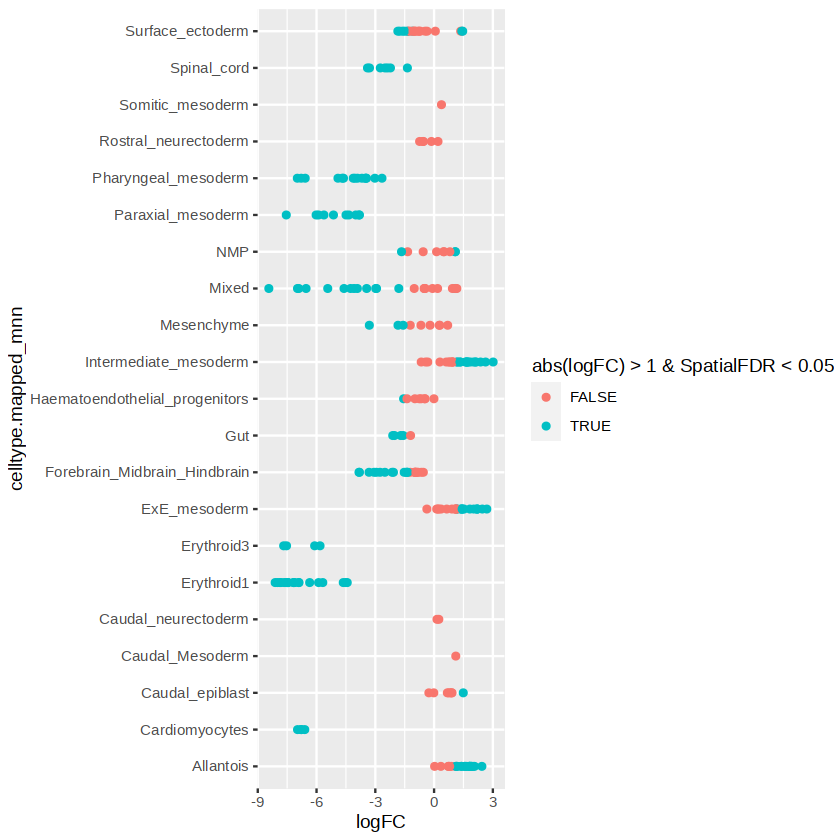

In [87]:
ggplot(da_results, aes(logFC, celltype.mapped_mnn, col=abs(logFC)>1 & SpatialFDR<0.05)) + 
    geom_point()

In [92]:
plotDAbeeswarm

function (da.res, group.by = NULL, alpha = 0.1, subset.nhoods = NULL) 
{
    if (!is.null(group.by)) {
        if (!group.by %in% colnames(da.res)) {
            stop(group.by, " is not a column in da.res. Have you forgot to run annotateNhoods(x, da.res, ", 
                group.by, ")?")
        }
        if (is.numeric(da.res[, group.by])) {
            stop(group.by, " is a numeric variable. Please bin to use for grouping.")
        }
        da.res <- mutate(da.res, group_by = da.res[, group.by])
    }
    else {
        da.res <- mutate(da.res, group_by = "g1")
    }
    if (!is.factor(da.res[, "group_by"])) {
        message("Converting group.by to factor...")
        da.res <- mutate(da.res, factor(group_by, levels = unique(group_by)))
    }
    if (!is.null(subset.nhoods)) {
        da.res <- da.res[subset.nhoods, ]
    }
    da.res %>% mutate(is_signif = ifelse(SpatialFDR < alpha, 
        1, 0)) %>% mutate(logFC_color = ifelse(is_signif == 1, 
        logFC, NA)) %>% arrange(group_by) %>% mutate(Nhood = factor(Nhood, 
        levels = unique(Nhood))) %>% ggplot(aes(group_by, logFC, 
        color = logFC_color)) + scale_color_gradient2() + guides(color = "none") + 
        xlab(group.by) + ylab("Log Fold Change") + geom_quasirandom(alpha = 1) + 
        coord_flip() + theme_bw(base_size = 22) + theme(strip.text.y = element_text(angle = 0))
}
<bytecode: 0x5652c81dfc70>
<environment: namespace:miloR>

In [120]:
test = function (da.res, group.by = NULL, alpha = 0.1, subset.nhoods = NULL) 
{
    if (!is.null(group.by)) {
        if (!group.by %in% colnames(da.res)) {
            stop(group.by, " is not a column in da.res. Have you forgot to run annotateNhoods(x, da.res, ", 
                group.by, ")?")
        }
        if (is.numeric(da.res[, group.by])) {
            stop(group.by, " is a numeric variable. Please bin to use for grouping.")
        }
        da.res <- mutate(da.res, group_by = da.res[, group.by])
    }
    else {
        da.res <- mutate(da.res, group_by = "g1")
    }
    if (!is.factor(da.res[, "group_by"])) {
        message("Converting group.by to factor...")
        da.res <- mutate(da.res, factor(group_by, levels = unique(group_by)))
    }
    if (!is.null(subset.nhoods)) {
        da.res <- da.res[subset.nhoods, ]
    }
    da.res %>% mutate(is_signif = ifelse(SpatialFDR < alpha, 
        1, 0)) %>% mutate(logFC_color = ifelse(is_signif == 1, 
        logFC, 0)) %>% arrange(group_by) %>% mutate(Nhood = factor(Nhood, 
        levels = unique(Nhood))) %>% ggplot(aes(group_by, logFC, 
        color = logFC_color)) + scale_color_gradient2(mid='grey90') + guides(color = "none") + 
        xlab(group.by) + ylab("Log Fold Change") + ggbeeswarm::geom_quasirandom(alpha = 1) + 
        coord_flip() + theme_bw(base_size = 22) + theme(strip.text.y = element_text(angle = 0))
}

Converting group.by to factor...



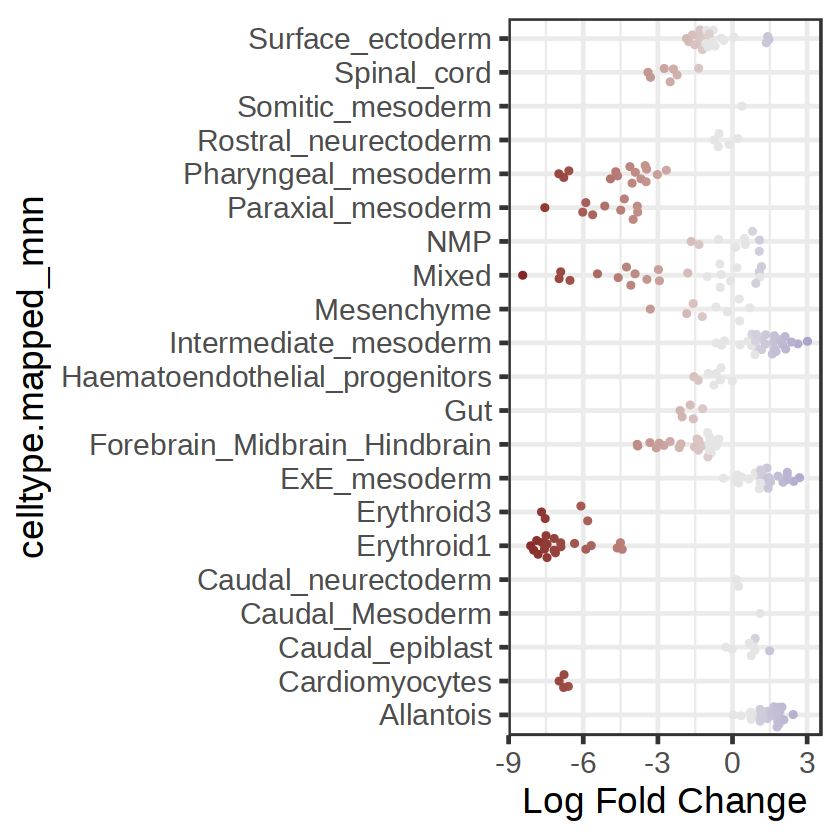

In [121]:
test(da_results, group.by = "celltype.mapped_mnn", alpha = 0.1)

Converting group.by to factor...

Warning message:
“Removed 96 rows containing missing values.”


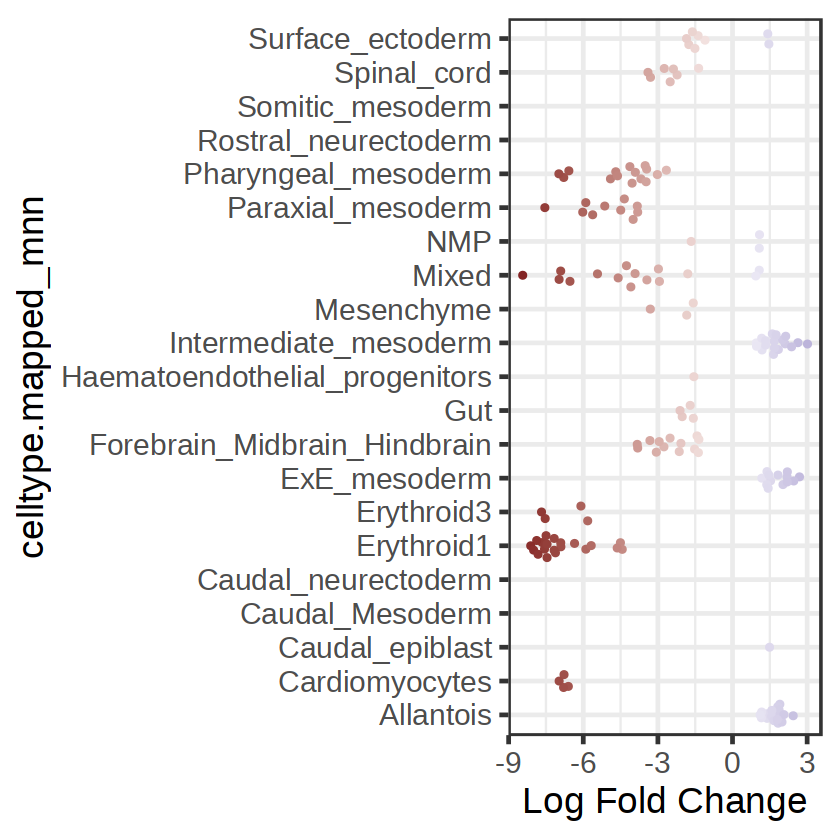

In [90]:
plotDAbeeswarm(da_results, group.by = "celltype.mapped_mnn", alpha = 0.05)